--- ONE-CLASS SVM PE GPU VIA PYTORCH (RBF KERNEL - 2018) ---
Dispozitiv detectat: cuda
Încărcare date...
Antrenare în curs pe GPU (20000 rânduri)...
Antrenare pe GPU finalizată în 4.84 secunde.

RAPORT FINAL:
 SISTEM AUDIT - REZULTATE ONE-CLASS PYTORCH GPU (OPTIMIZAT FN - 2018)
Scor AUC: 0.8341
Timp Antrenare GPU: 4.84s
              precision    recall  f1-score   support

      Normal       0.60      0.59      0.60      2556
    Anomalie       0.86      0.87      0.86      7444

    accuracy                           0.80     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.79      0.80      0.80     10000



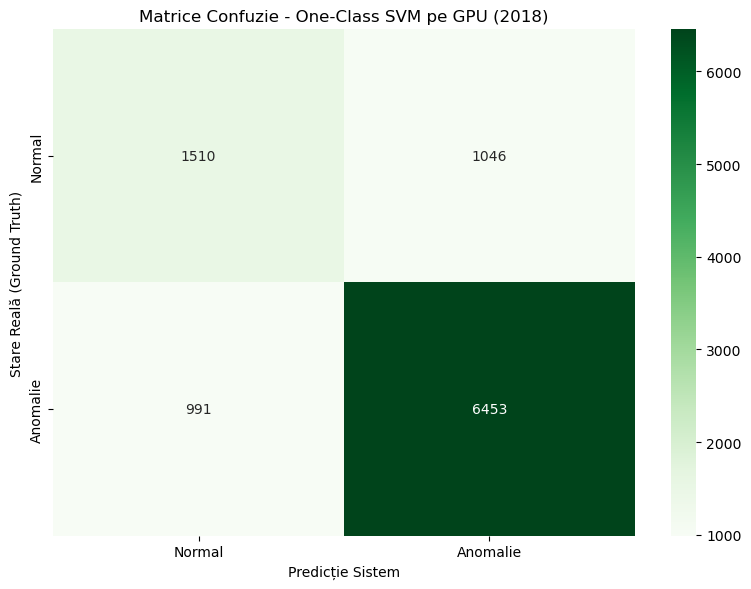

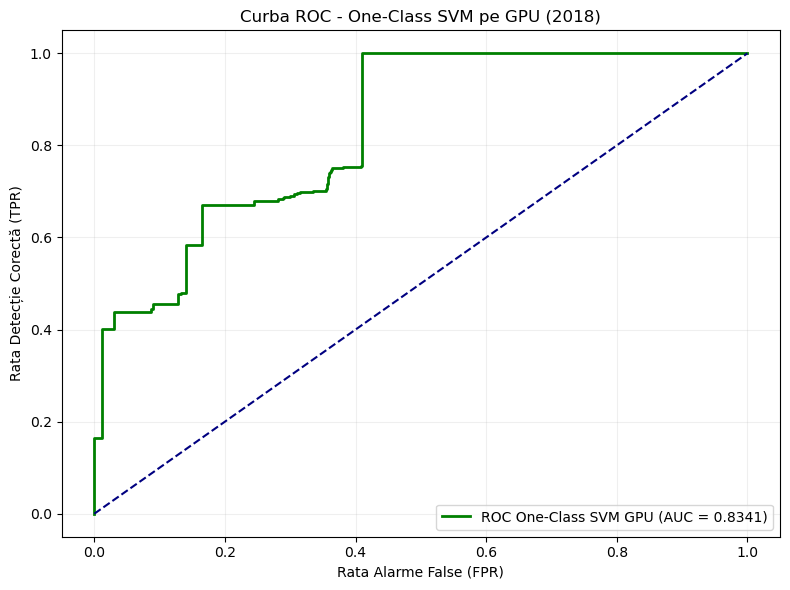

Rezultate salvate în: D:\disertatie\rezultate_2018\One_class_SVM


In [2]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

data_path = r'D:\disertatie\preprocesare_anomalii_2018'
model_save_path = r'D:\disertatie\modele_2018\One_class_SVM'
rezultate_path = r'D:\disertatie\rezultate_2018\One_class_SVM'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- ONE-CLASS SVM PE GPU VIA PYTORCH (RBF KERNEL - 2018) ---")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispozitiv detectat: {device}")

print("Încărcare date...")
X_train_full = torch.load(os.path.join(data_path, 'X_train_2018.pt'), map_location=device).float()
X_test_full = torch.load(os.path.join(data_path, 'X_test_2018.pt'), map_location=device).float()
y_test_full = torch.load(os.path.join(data_path, 'y_test_2018.pt'), map_location=device)

np.random.seed(42)
n_train = 20000  
n_test = 10000

idx_train = np.random.choice(X_train_full.shape[0], n_train, replace=False)
X_train_raw = X_train_full[idx_train]

idx_test = np.random.choice(X_test_full.shape[0], n_test, replace=False)
X_test_raw = X_test_full[idx_test]
y_test_tensor = y_test_full[idx_test]

y_test_cpu = y_test_tensor.cpu().numpy()

mean = X_train_raw.mean(dim=0)
std = X_train_raw.std(dim=0)
std[std == 0] = 1.0

X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std

class PyTorchRBFOneClassSVM(nn.Module):
    def __init__(self, X_anchor, gamma):
        super(PyTorchRBFOneClassSVM, self).__init__()
        self.X_anchor = X_anchor
        n_anchors = X_anchor.shape[0]
        self.gamma = gamma
        self.alpha = nn.Parameter(torch.randn(n_anchors, 1) * 0.01)
        self.rho = nn.Parameter(torch.zeros(1))
        
    def _compute_kernel(self, x):
        dist_matrix = torch.cdist(x, self.X_anchor, p=2)
        return torch.exp(-self.gamma * (dist_matrix ** 2))
        
    def forward(self, x):
        K = self._compute_kernel(x)
        return torch.matmul(K, self.alpha) - self.rho

gamma_val = 1.0 / X_train.shape[1]
model = PyTorchRBFOneClassSVM(X_train, gamma_val).to(device)

nu = 0.35
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 150
batch_size = 4096

start_time = time.time()
print(f"Antrenare în curs pe GPU ({n_train} rânduri)...")

model.train()
for epoch in range(epochs):
    permutation = torch.randperm(n_train)
    
    for i in range(0, n_train, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_train[indices]
        
        optimizer.zero_grad()
        scores = model(batch_x)
        
        hinge_loss = torch.mean(torch.clamp(1.0 - scores, min=0.0))
        reg_loss = 0.5 * torch.sum(model.alpha ** 2)
        loss = reg_loss + (1.0 / nu) * hinge_loss - model.rho
        
        loss.backward()
        optimizer.step()

train_time = time.time() - start_time
print(f"Antrenare pe GPU finalizată în {train_time:.2f} secunde.")

torch.save(model.state_dict(), os.path.join(model_save_path, 'pytorch_ocsvm_rbf_gpu.pt'))

model.eval()
with torch.no_grad():
    test_scores = model(X_test).squeeze().cpu().numpy()

percentila_dorita = 75
prag_dinamic = np.percentile(test_scores, percentila_dorita)
y_pred = (test_scores < prag_dinamic).astype(int)

y_scores = -test_scores
if confusion_matrix(y_test_cpu, y_pred)[0, 0] == 0:
    y_pred = 1 - y_pred
    y_scores = -y_scores

fpr, tpr, _ = roc_curve(y_test_cpu, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test_cpu, y_pred, target_names=['Normal', 'Anomalie'])
full_text = f"SISTEM AUDIT - REZULTATE ONE-CLASS PYTORCH GPU (OPTIMIZAT FN - 2018)\n"
full_text += f"Scor AUC: {roc_auc:.4f}\n"
full_text += f"Timp Antrenare GPU: {train_time:.2f}s\n"
full_text += "="*50 + "\n"
full_text += report

print("\nRAPORT FINAL:\n", full_text)
with open(os.path.join(rezultate_path, 'raport_final_ocsvm_gpu.txt'), 'w') as f:
    f.write(full_text)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_cpu, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.title('Matrice Confuzie - One-Class SVM pe GPU (2018)')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_ocsvm_2018_gpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC One-Class SVM GPU (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Curba ROC - One-Class SVM pe GPU (2018)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'roc_ocsvm_2018_gpu.png'), dpi=300)
plt.show()

print(f"Rezultate salvate în: {rezultate_path}")